# Commodity Equity Alpha

The main approach in this model is examining and trading the relationship between physical producers / users equity alpha and commodities returns. The equity alpha for commodities producer is the excess return attribute to the individual companies. Equity investors may be attributing excess returns to commodity companies which the commodities market doesn't fully price in.

We'll first by using various commodity ETFs and their respective Commodity Futures. 

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

# Preparing data

In [2]:
df_eq = (pd.read_parquet(
    path = "eq_px.parquet").
    query("variable == 'Adj Close'").
    pivot(index = "date", columns = "ticker", values = "value").
    pct_change().
    reset_index().
    melt(id_vars = ["date", "SPY"]).
    dropna())

In [3]:
df_fut = (pd.read_parquet(
    path = "commod_px.parquet").
    assign(security = lambda x: x.security.str.split("1").str[0].str.strip()).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    pct_change().
    reset_index().
    melt(id_vars = ["date"], var_name = "fut_ticker", value_name = "fut_rtn").
    dropna().
    assign(date = lambda x: pd.to_datetime(x.date).dt.date))

In [4]:
df_relationship = pd.read_excel(io = "tickers.xlsx", sheet_name = "relationship")

In [55]:
df_ticker = (pd.read_excel(
    io         = "tickers.xlsx", 
    sheet_name = "relationship").
    assign(
        tmp       = lambda x: x.Name.str.replace("VanEck", "").str.replace("ETF", "").str.replace("and", "&").str.replace("Metals", ""),
        group_var = lambda x: x.Ticker + " " + x.fut_ticker))

# Building out the model

First start by seperating out the alpha in equities. In this case use a 30 day rolling OLS regression and SPY as a benchmark. 

In [5]:
def _get_ols(df: pd.DataFrame, window: int = 30) -> pd.DataFrame: 
    
    df_out = (RollingOLS(
        endog  = df.value,
        exog   = sm.add_constant(df.SPY),
        window = window).
        fit().
        params.
        rename(columns = {"SPY": "beta"}).
        merge(right = df, how = "inner", on = ["date"]))
    
    return df_out

df_alpha = (df_eq.set_index(
    "date").
    groupby("ticker").
    apply(_get_ols).
    drop(columns = ["ticker"]).
    reset_index().
    dropna())

Below is the rolling alphas of the commodity etfs to the SPY.

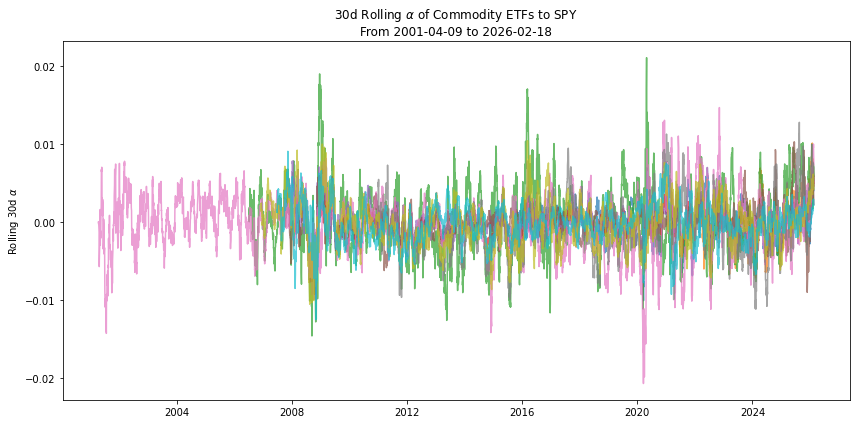

In [26]:
(df_alpha.pivot(
    index = "date", columns = "ticker", values = "const").
    plot(
        ylabel  = r"Rolling 30d $\alpha$",
        legend  = False,
        xlabel  = "",
        figsize = (12,6),
        alpha   = 0.7,
        title   = r"30d Rolling $\alpha$ of Commodity ETFs to SPY" + "\nFrom {} to {}".format(
            df_alpha.date.min(),
            df_alpha.date.max())))

plt.tight_layout()

In [27]:
df_combined = (df_relationship.rename(
    columns = {"Ticker": "ticker"}).
    assign(Name = lambda x: x.Name.str.replace("VanEck", "").str.replace("ETF", "")).
    merge(right = df_alpha, how = "inner", on = ["ticker"]).
    merge(right = df_fut, how = "inner", on = ["fut_ticker", "date"]))

In [28]:
def _get_resid(df: pd.DataFrame, q: int = 10) -> pd.DataFrame: 
    
    df_tmp = df.sort_index()
    df_out = (sm.OLS(
        endog  = df_tmp.fut_rtn,
        exog   = sm.add_constant(df_tmp.const)).
        fit().
        resid.
        to_frame(name = "resid").
        assign(
            lag_resid = lambda x: x.resid.shift(),
            decile    = lambda x: pd.qcut(x = x.resid, q = q, labels = [i + 1 for i in range(q)]).shift()).
        merge(right = df, how = "inner", on = ["date"]))
    
    return df_out

df_signal = (df_combined.assign(
    group_var = lambda x: x.ticker + " " + x.fut_ticker).
    set_index("date").
    groupby("group_var").
    apply(_get_resid).
    drop(columns = ["group_var"]).
    reset_index())

In [29]:
def _model(df: pd.DataFrame) -> pd.DataFrame: 
    
    df_tmp = df.sort_index()
    model1 = (sm.OLS(
        endog  = df_tmp.fut_rtn,
        exog   = sm.add_constant(df_tmp.alpha)).
        fit())
    
    df_param_val = (model1.params.to_frame(
        name = "param_val").reset_index())
    
    df_pvalue = (model1.pvalues.to_frame(
        name = "pvalue").reset_index())
    
    df_tstat = (model1.tvalues.to_frame(
        name = "tstat").reset_index())
    
    df_out = (df_param_val.merge(
        right = df_pvalue, how = "inner", on = ["index"]).
        merge(right = df_tstat, how = "inner", on = ["index"]))
    
    return df_out

def _get_coefs(df: pd.DataFrame, q: int = 10) -> pd.DataFrame: 
    
    df_lag0 = _model(df).assign(model = "lag_0")
    df_lag  = df.sort_index().assign(alpha = lambda x: x.alpha.shift()).dropna()
    df_lag1 = _model(df_lag).assign(model = "lag_1")
    
    df_out = pd.concat([df_lag0, df_lag1])
    return df_out

df_coefs = (df_combined.assign(
    group_var = lambda x: x.ticker + " " + x.fut_ticker).
    set_index("date").
    rename(columns = {"const": "alpha"}).
    groupby("group_var").
    apply(_get_coefs))

Then we pass those rolling alphas into a regression against their respective commodities. Below is the results of that regression

In [30]:
(df_coefs.reset_index().drop(
    columns = ["level_1"]).
    assign(
        ticker     = lambda x: x.group_var.str.split(" ").str[0],
        fut_ticker = lambda x: x.group_var.str.split(" ").str[1]).
    drop(columns = ["group_var"]).
    rename(columns = {"index": "param"}).
    melt(id_vars = ["param", "fut_ticker", "model", "ticker"]).
    replace({
        "param_val": "Param. Val",
        "pvalue"   : "p-value",
        "tstat"    : "t-stat",
        "lag_0"    : "No-Lag",
        "lag_1"    : "Lagged",
        "alpha"    : r"Equity $\alpha$"}).
    pivot(index = ["fut_ticker", "ticker", "param"], columns = ["variable", "model"], values = "value").
    apply(lambda x: np.round(x,3)))

variable                          Param. Val        p-value         t-stat  \
model                                 No-Lag Lagged  No-Lag Lagged  No-Lag   
fut_ticker ticker param                                                      
BO         MOO    Equity $\alpha$      0.731  0.387   0.000  0.005   5.362   
                  const                0.000  0.000   0.244  0.342   1.165   
CC         MOO    Equity $\alpha$      0.260  0.105   0.150  0.563   1.439   
                  const                0.001  0.001   0.084  0.098   1.731   
CL         OIH    Equity $\alpha$      1.332  1.042   0.000  0.000   7.905   
                  const                0.000 -0.000   0.990  0.881   0.012   
CO         OIH    Equity $\alpha$      0.852  0.373   0.000  0.000  10.998   
                  const                0.001  0.001   0.007  0.037   2.677   
CT         MOO    Equity $\alpha$      0.466  0.283   0.002  0.058   3.131   
                  const                0.000  0.000   0.528  0.599   0.632   
FC         MOO    Equity $\alpha$     -0.040 -0.021   0.616  0.800  -0.501   
                  const                0.000  0.000   0.463  0.447   0.734   
GC         GDX    Equity $\alpha$      0.402  0.058   0.000  0.129  10.650   
                  const                0.000  0.000   0.060  0.021   1.882   
HG         EMET   Equity $\alpha$      0.686  0.095   0.000  0.610   3.726   
                  const                0.001  0.000   0.307  0.479   1.023   
HO         CRAK   Equity $\alpha$      0.916  0.486   0.000  0.011   4.785   
                  const                0.001  0.001   0.220  0.220   1.226   
KC         MOO    Equity $\alpha$      0.080 -0.153   0.652  0.387   0.452   
                  const                0.000  0.000   0.449  0.523   0.758   
LC         MOO    Equity $\alpha$      0.039 -0.010   0.649  0.905   0.456   
                  const                0.000  0.000   0.461  0.490   0.737   
LH         MOO    Equity $\alpha$      0.052  0.010   0.709  0.944   0.373   
                  const                0.000  0.000   0.384  0.392   0.871   
NG         CRAK   Equity $\alpha$     -0.053 -0.146   0.871  0.653  -0.162   
                  const                0.000  0.000   0.675  0.678   0.419   
QS         CRAK   Equity $\alpha$      0.903  0.411   0.000  0.043   4.468   
                  const                0.001  0.001   0.270  0.259   1.103   
S          MOO    Equity $\alpha$      0.555  0.226   0.000  0.062   4.601   
                  const                0.000  0.000   0.038  0.066   2.071   
SB         MOO    Equity $\alpha$      0.463  0.269   0.005  0.104   2.806   
                  const                0.000  0.000   0.302  0.350   1.033   
SM         MOO    Equity $\alpha$      0.438  0.181   0.002  0.195   3.148   
                  const                0.001  0.001   0.007  0.012   2.683   
W          MOO    Equity $\alpha$      0.488  0.214   0.005  0.219   2.800   
                  const               -0.000 -0.000   0.379  0.315  -0.880   
XB         CRAK   Equity $\alpha$      1.002  0.497   0.000  0.020   4.718   
                  const                0.001  0.001   0.247  0.247   1.157   

variable                                  
model                             Lagged  
fut_ticker ticker param                   
BO         MOO    Equity $\alpha$  2.828  
                  const            0.951  
CC         MOO    Equity $\alpha$  0.578  
                  const            1.656  
CL         OIH    Equity $\alpha$  6.170  
                  const           -0.149  
CO         OIH    Equity $\alpha$  4.780  
                  const            2.084  
CT         MOO    Equity $\alpha$  1.898  
                  const            0.526  
FC         MOO    Equity $\alpha$ -0.254  
                  const            0.761  
GC         GDX    Equity $\alpha$  1.518  
                  const            2.311  
HG         EMET   Equity $\alpha$  0.510  
                  const    

In [31]:
df_signal_rtn = (df_signal.assign(
    signal_rtn = lambda x: -np.sign(x.lag_resid) * x.fut_rtn).
    query("ticker != 'EMET'").
    rename(columns = {"group_var": ""}).
    pivot(index = "date", columns = "", values = "signal_rtn").
    dropna().
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    assign(Average = lambda x: x.mean(axis = 1)))

Here is the results of trading the residuals of that regression

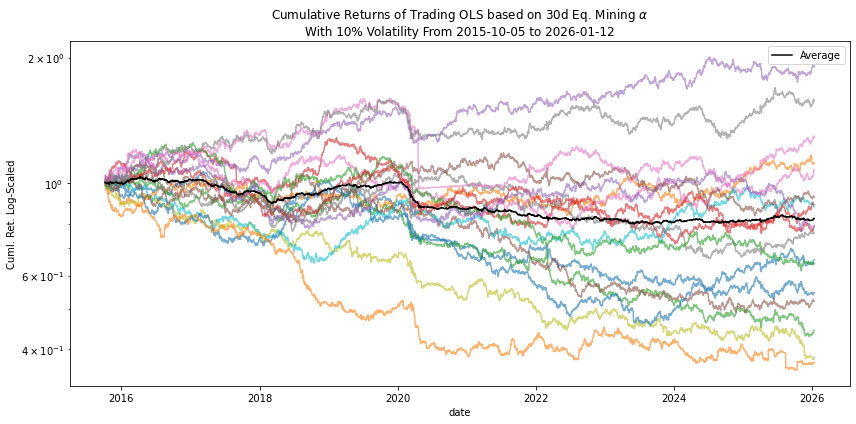

In [32]:
fig, axes = plt.subplots(figsize = (12,6))

(df_signal_rtn.drop(
    columns = ["Average"]).
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        ax     = axes,
        logy   = True,
        alpha  = 0.6,
        legend = False))

(df_signal_rtn[
    ["Average"]].
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        logy   = True, 
        ax     = axes,
        color  = "black",
        ylabel = "Cuml. Ret. Log-Scaled",
        title  = "Cumulative Returns of Trading OLS based on " + r"30d Eq. Mining $\alpha$" + "\nWith 10% Volatility From {} to {}".format(
            df_signal_rtn.index.min(),
            df_signal_rtn.index.max())))

plt.tight_layout()

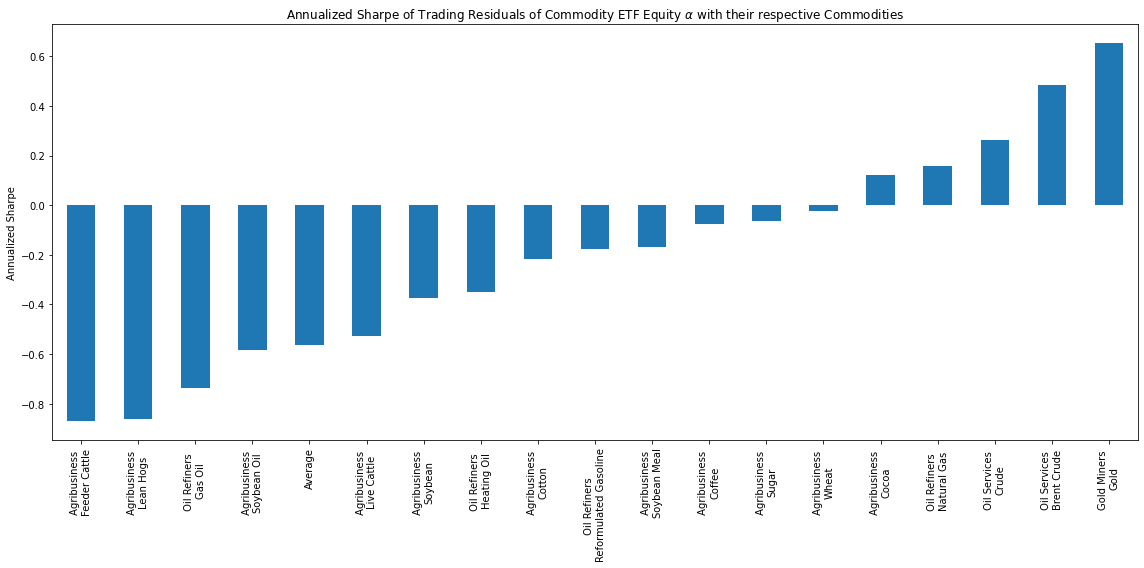

In [70]:
(df_signal_rtn.agg(
    lambda x: x.mean() / x.std() * np.sqrt(252)).
    to_frame(name = "sharpe").
    reset_index().
    rename(columns = {"": "group_var"}).
    merge(right = df_ticker, how = "left", on = ["group_var"]).
    assign(name = lambda x: (x.tmp + "\n" + x.fut_name).fillna(x.group_var)).
    set_index("name")
    [["sharpe"]].
    sort_values("sharpe").
    plot(
        kind    = "bar", 
        figsize = (16,8),
        xlabel  = "",
        ylabel  = "Annualized Sharpe",
        legend  = False,
        title   = r"Annualized Sharpe of Trading Residuals of Commodity ETF Equity $\alpha$ with their respective Commodities"))

plt.tight_layout()

In [12]:
df_signal_wider = (df_signal.assign(
    signal_rtn = lambda x: -np.sign(x.lag_resid) * x.fut_rtn).
    pivot(index = "date", columns = ["Name", "fut_name"], values = "signal_rtn"))

In [13]:
df_rsk_rtn = (df_signal_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(group = "vol_hedged"))

In [14]:
df_perf_rtn = (df_signal_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(group = "perf_hedged"))

In [15]:
df_date = (df_rsk_rtn[
    ["date", "Name", "fut_name"]].
    groupby(["Name", "fut_name"]).
    agg("min").
    reset_index())

Also account for volatility targetting done perfectly this is for representing intraday volatility targetting

In [16]:
display(pd.concat([
    df_rsk_rtn, df_perf_rtn]).
    drop(columns = ["date"]).
    groupby(["Name", "fut_name", "group"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    pivot(index = ["Name", "fut_name"], columns = "group", values = "rtn").
    apply(lambda x: np.round(x,3)).
    reset_index().
    merge(right = df_date, how = "inner", on = ["Name", "fut_name"])
    [["date", "Name", "fut_name", "vol_hedged", "perf_hedged"]].
    rename(columns = {
        "date"       : "Start Date",
        "fut_name"   : "Fut",
        "vol_hedged" : "Vol Targatted",
        "perf_hedged": "Perfectly Targetted"}))

,Start Date,Name,Fut,Vol Targatted,Perfectly Targetted
0,2007-10-22,Agribusiness,Cocoa,-0.120,-0.113
1,2007-10-22,Agribusiness,Coffee,0.093,0.127
2,2007-10-22,Agribusiness,Cotton,-0.494,-0.485
3,2007-10-22,Agribusiness,Feeder Cattle,-1.295,-1.306
4,2007-10-22,Agribusiness,Lean Hogs,-1.031,-1.037
5,2007-10-22,Agribusiness,Live Cattle,-0.330,-0.221
6,2007-10-22,Agribusiness,Soybean,-0.196,-0.169
7,2007-10-22,Agribusiness,Soybean Meal,-0.167,-0.159
8,2007-10-22,Agribusiness,Soybean Oil,-0.525,-0.514
9,2007-10-22,Agribusiness,Sugar,-0.324,-0.311


In [17]:
df_decile_sharpe = (df_signal[
    ["group_var", "decile", "fut_rtn"]].
    dropna().
    groupby(["group_var", "decile"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"fut_rtn": "sharpe"}))

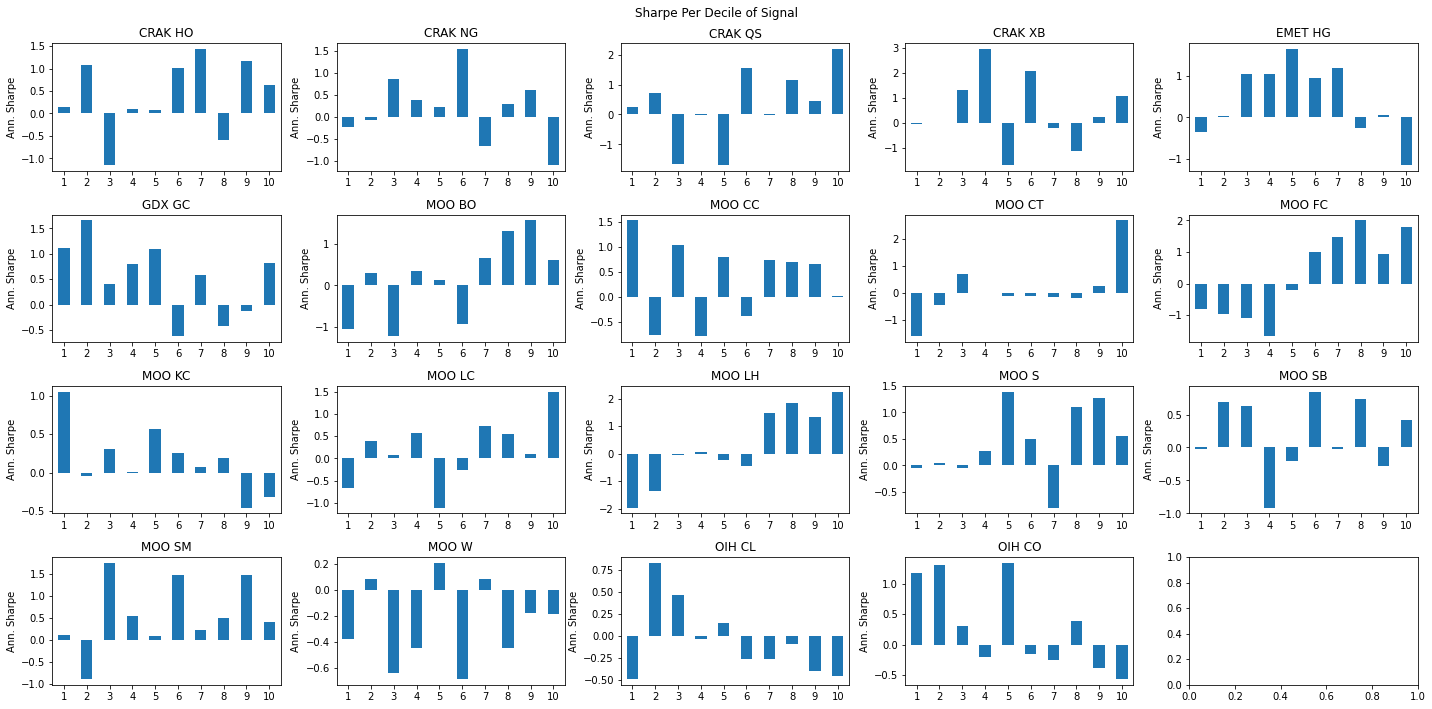

In [18]:
groups_vars = df_decile_sharpe.group_var.drop_duplicates().sort_values().to_list()
fig, axes   = plt.subplots(ncols = 5, nrows = 4, figsize = (20,10))

for group_var, ax in zip(groups_vars, axes.flatten()):
    
    (df_decile_sharpe.query(
        "group_var == @group_var").
        set_index("decile")
        [["sharpe"]].
        plot(
            kind   = "bar",
            ax     = ax,
            title  = group_var,
            legend = False,
            ylabel = "Ann. Sharpe",
            xlabel = "",
            rot    = 0))
    
fig.suptitle("Sharpe Per Decile of Signal")
plt.tight_layout()

In [19]:
df_grouper = (df_decile_sharpe.query(
    "decile == [1,2,9,10]").
    assign(group = lambda x: np.where(x.decile <= 2, "lower", "upper")))

In [20]:
df_opt_signal = (df_grouper[
    ["group_var", "group", "sharpe"]].
    assign(sharpe = lambda x: np.where(np.abs(x.sharpe) > 0.2, x.sharpe, 0)).
    groupby(["group_var", "group"]).
    agg("prod").
    reset_index().
    assign(scaler = lambda x: np.where(x.sharpe > 0, 1, np.nan)).
    drop(columns = ["sharpe"]).
    merge(right = df_grouper, how = "inner", on = ["group_var", "group"]).
    assign(signal = lambda x: x.scaler * x.sharpe).
    dropna())

In [21]:
df_opt_rtn = (df_signal.merge(
    right = df_opt_signal, how = "right", on = ["decile", "group_var"]).
    assign(signal_rtn = lambda x: np.sign(x.signal) * x.fut_rtn))

In [22]:
df_opt_rsk_rtn = (df_opt_rtn.pivot(
    index = "date", columns = "group_var", values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date").
    assign(
        group  = lambda x: x.group_var.str.split(" ").str[0],
        ticker = lambda x: x.group_var.str.split(" ").str[1]).
    dropna())

In [23]:
renamer = (df_signal[
    ["ticker", "Name"]].
    assign(Name = lambda x: x.Name.str.strip()).
    drop_duplicates().
    set_index("ticker").
    Name.
    to_dict())

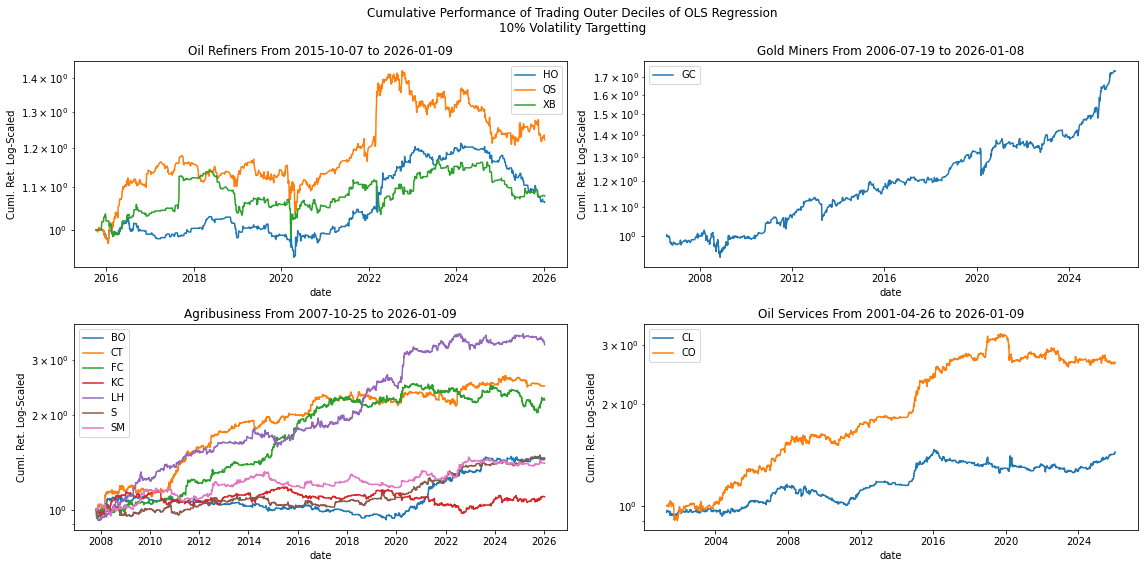

In [24]:
groups    = df_opt_rsk_rtn.group.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (16,8))

for group, ax in zip(groups, axes.flatten()): 
    
    df_tmp = (df_opt_rsk_rtn.query(
        "group == @group").
        rename(columns = {"ticker": ""}).
        query("value <= 0.4").
        pivot(index = "date", columns = "", values = "value").
        fillna(0).
        apply(lambda x: np.cumprod(1 + x)))
    
    (df_tmp.
        plot(
            logy   = True,
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = "{} From {} to {}".format(
                renamer[group],
                df_tmp.index.min(),
                df_tmp.index.max())))
    
fig.suptitle("Cumulative Performance of Trading Outer Deciles of OLS Regression\n10% Volatility Targetting")
plt.tight_layout()

In [25]:
df_opt_rtn_wider = (df_opt_rtn.pivot(
    index = "date", columns = "group_var", values = "signal_rtn"))

In [26]:
df_lag1 = (df_opt_rtn_wider.
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date").
    assign(
        raw_rtn = lambda x: x.value.fillna(0),
        group   = "lag_1").
    rename(columns = {"value": "adj_rtn"}))

df_lag0 = (df_opt_rtn_wider.
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std()* np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = "date").
    assign(
        raw_rtn = lambda x: x.value.fillna(0),
        group   = "lag_0").
    rename(columns = {"value": "adj_rtn"}))

In [27]:
df_namer = (df_signal[
    ["group_var", "Name", "fut_ticker"]].
    drop_duplicates())

In [28]:
(pd.concat([
    df_lag1, df_lag0]).
    melt(id_vars = ["date", "group_var", "group"]).
    dropna().
    drop(columns = ["date"]).
    merge(right = df_namer, how = "inner", on = ["group_var"]).
    drop(columns = ["group_var"]).
    groupby(["Name", "fut_ticker", "group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "group"     : "Target Type",
        "fut_ticker": "Fut",
        "variable"  : ""}).
    replace({
        "lag_0"   : "Perfect Targetting",
        "lag_1"   : "Vol Targetting",
        "adj_rtn" : "Adj. Ret",
        "raw_rtn" : "Raw Return"}).
    pivot(index = ["Name", "Fut"], columns = ["Target Type", ""], values = "value").
    apply(lambda x: np.round(x,3)))

Target Type         Perfect Targetting            Vol Targetting           
                              Adj. Ret Raw Return       Adj. Ret Raw Return
Name            Fut                                                        
 Agribusiness   BO               0.775      0.327          1.050      0.442
                CT               1.245      0.742          1.244      0.741
                FC               1.151      0.686          1.093      0.652
                KC               0.456      0.193          0.294      0.124
                LH               1.740      1.035          1.680      1.000
                S                1.028      0.434          1.039      0.438
                SM               0.922      0.389          0.956      0.403
 Oil Refiners   HO               0.402      0.127          0.349      0.111
                QS               0.676      0.303          0.537      0.241
                XB               0.450      0.143          0.417      0.132
 Oil Services   CL               0.977      0.480          0.749      0.368
                CO               1.111      0.772          0.999      0.694
Gold Miners     GC               1.666      0.725          1.468      0.639

Text(0.5, 1.0, 'Correlation Matrix amongst decile-optimized signal')

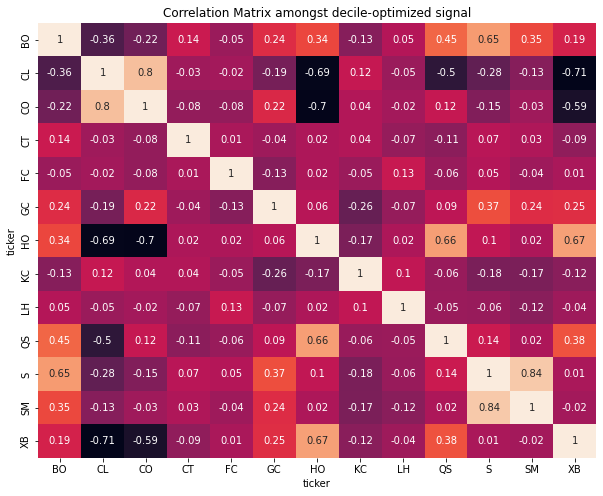

In [29]:
df_corr = (df_opt_rsk_rtn.pivot(
    index = "date", columns = "ticker", values = "value").
    corr().
    apply(lambda x: np.round(x,2)))

fig, axes = plt.subplots(figsize = (10,8))

sns.heatmap(
    data  = df_corr,
    cbar  = False,
    annot = True)

axes.set_title("Correlation Matrix amongst decile-optimized signal")

In [30]:
df_name_rtn = (df_opt_rtn.pivot(
    index = "date", columns = ["Name", "fut_ticker"], values = "signal_rtn").
    fillna(0).
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.4, np.nan, x)).
    reset_index().
    melt(id_vars = ["date"], value_name = "rtn").
    drop(columns = ["fut_ticker"]).
    dropna().
    groupby(["date", "Name"]).
    agg("mean").
    assign(group = "vol_target"))

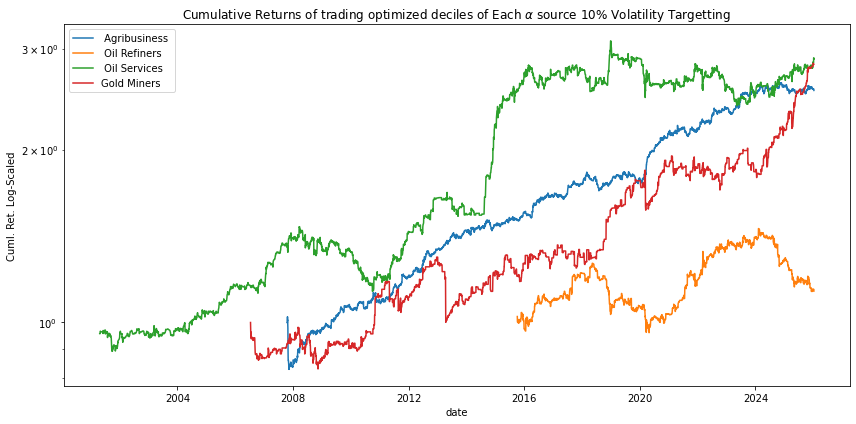

In [31]:
(df_name_rtn.
    reset_index().
    rename(columns = {"Name": ""}).
    pivot(index = "date", columns = "", values = "rtn").
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        figsize = (12,6),
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = r"Cumulative Returns of trading optimized deciles of Each $\alpha$ source 10% Volatility Targetting"))

plt.tight_layout()

In [32]:
df_perf_name_rtn = (df_opt_rtn.pivot(
    index = "date", columns = ["Name", "fut_ticker"], values = "signal_rtn").
    fillna(0).
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.4, np.nan, x)).
    reset_index().
    melt(id_vars = ["date"], value_name = "rtn").
    drop(columns = ["fut_ticker"]).
    dropna().
    groupby(["date", "Name"]).
    agg("mean").
    assign(group = "perf"))

In [33]:
(pd.concat([
    df_perf_name_rtn, df_name_rtn]).
    reset_index().
    rename(columns = {"rtn": "raw_rtn"}).
    assign(adj_rtn = lambda x: np.where(x.raw_rtn == 0, np.nan, x.raw_rtn)).
    melt(id_vars = ["date", "Name", "group"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["Name", "group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {
        "group"   : "Vol. Target",
        "variable": ""}).
    replace({
        "perf"      : "Perfect Targetting",
        "vol_target": "Vol Targetting",
        "raw_rtn"   : "Raw Sharpe",
        "adj_rtn"   : "Adj Sharpe"}).
    pivot(index = "Name", columns = ["Vol. Target", ""], values = "value").
    apply(lambda x: np.round(x,3)))

Vol. Target     Perfect Targetting            Vol Targetting           
                        Adj Sharpe Raw Sharpe     Adj Sharpe Raw Sharpe
Name                                                                   
 Agribusiness                1.274      1.224          1.123      1.078
 Oil Refiners                0.520      0.377          0.269      0.195
 Oil Services                0.934      0.682          0.830      0.606
Gold Miners                  1.701      0.788          1.183      0.549

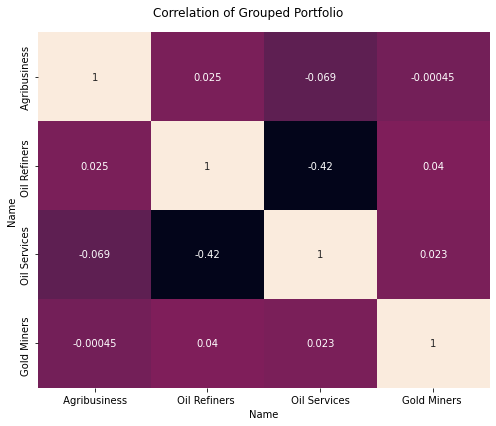

In [34]:
df_corr = (df_name_rtn.reset_index().pivot(
    index = "date", columns = "Name", values = "rtn").
    corr())

fig, axes = plt.subplots(figsize = (7,6))

sns.heatmap(
    ax    = axes,
    data  = df_corr,
    annot = True,
    cbar  = False)

fig.suptitle("Correlation of Grouped Portfolio")
plt.tight_layout()

In [35]:
df_lagged = (df_opt_rtn.pivot(
    index = "date", columns = ["Name", "fut_ticker"], values = "signal_rtn").
    fillna(0).
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.4, np.nan, x)).
    mean(axis = 1).
    to_frame(name = "lagged_rtn"))

df_perf = (df_opt_rtn.pivot(
    index = "date", columns = ["Name", "fut_ticker"], values = "signal_rtn").
    fillna(0).
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 0.4, np.nan, x)).
    mean(axis = 1).
    to_frame(name = "perf"))

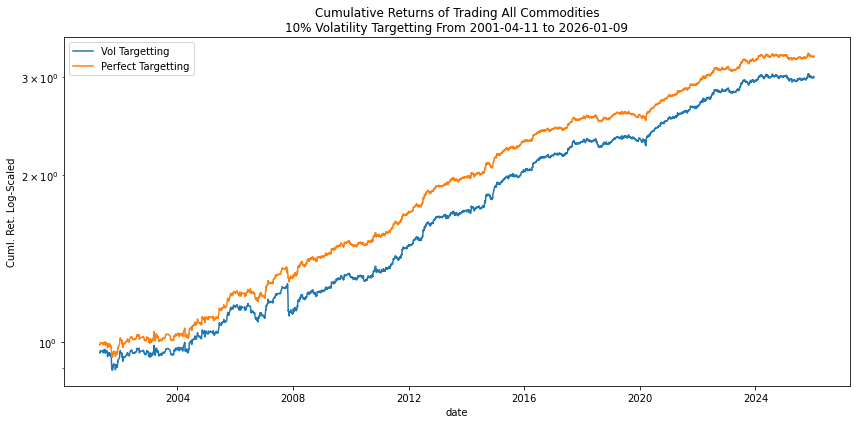

In [36]:
df_combined = (df_lagged.merge(
    right = df_perf, how = "inner", on = ["date"]).
    dropna())


(df_combined.
    apply(lambda x: np.cumprod(1 + x)).
    rename(columns = {
        "lagged_rtn": "Vol Targetting",
        "perf"      : "Perfect Targetting"}).
    plot(
        logy    = True,
        figsize = (12,6),
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Cumulative Returns of Trading All Commodities\n10% Volatility Targetting From {} to {}".format(
            df_perf.index.min(),
            df_perf.index.max())))

plt.tight_layout()

In [37]:
(df_combined.reset_index().melt(
    id_vars = "date", value_name = "raw_rtn").
    assign(adj_rtn = lambda x: np.where(x.raw_rtn == 0, np.nan, x.raw_rtn)).
    melt(id_vars = ["date", "variable"], var_name = "rtn_group", value_name = "rtn_val").
    drop(columns = ["date"]).
    dropna().
    groupby(["variable", "rtn_group"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    replace({
        "lagged_rtn": "Vol Targetted",
        "perf"      : "Perf Targetted"}).
    rename(columns = {"rtn_group": ""}).
    pivot(index = "variable", columns = "", values = "rtn_val").
    rename(columns = {
        "adj_rtn": "Adjusted Sharpe",
        "raw_rtn": "Raw Sharpe"}).
    apply(lambda x: np.round(x,3)))

,Adjusted Sharpe,Raw Sharpe
variable,,
Perf Targetted,1.407,1.404
Vol Targetted,1.121,1.118
